In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rwmcmc.samplers import random_walk_metropolis_hastings

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
rng = np.random.default_rng(42)

a_true = 10.0
b_true = 2.0
h0_true = 0.20

h_measured = np.array([
    0.35, 0.45, 0.60, 0.75, 0.90, 1.05, 1.20, 1.35, 1.50, 1.65,
    1.80, 1.95, 2.10, 2.25, 2.40, 2.55, 2.70, 2.85, 3.00, 3.15,
    3.30, 3.45, 3.60, 3.75, 3.90,
])

Q_true_values = a_true * (h_measured - h0_true) ** b_true
sigma_noise = 0.08
log_noise = rng.normal(0, sigma_noise, size=len(h_measured))
Q_measured = Q_true_values * np.exp(log_noise)

df = pd.DataFrame({
    "stage_m": h_measured,
    "discharge_m3s": Q_measured,
})
df.to_csv("data/rating_curve.csv", index=False)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nTrue parameters (for verification later):")
print(f"  a   = {a_true}")
print(f"  b   = {b_true}")
print(f"  h_0 = {h0_true}")
print(f"  sigma (log-noise) = {sigma_noise}")

Dataset shape: (25, 2)

First 5 rows:
   stage_m  discharge_m3s
0     0.35       0.230552
1     0.45       0.575105
2     0.60       1.699000
3     0.75       3.261399
4     0.90       4.191893

True parameters (for verification later):
  a   = 10.0
  b   = 2.0
  h_0 = 0.2
  sigma (log-noise) = 0.08


         stage_m  discharge_m3s
count  25.000000      25.000000
mean    2.102000      47.970963
std     1.100613      43.344983
min     0.350000       0.230552
25%     1.200000      10.102797
50%     2.100000      36.291201
75%     3.000000      84.107854
max     3.900000     132.288416


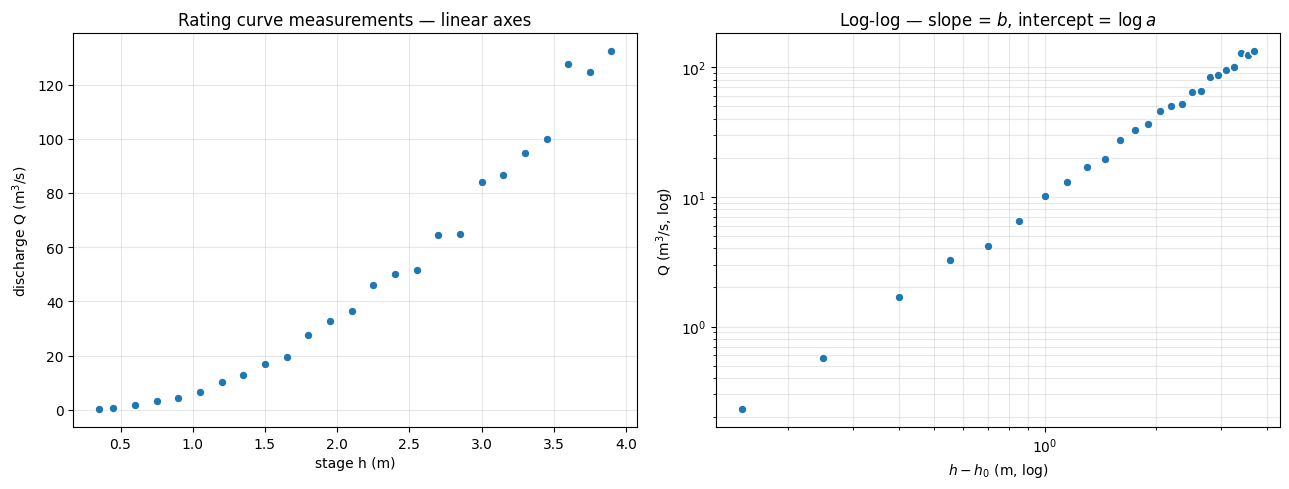

In [ ]:
df = pd.read_csv("data/rating_curve.csv")
h = df["stage_m"].values
Q = df["discharge_m3s"].values

print(df.describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(h, Q, s=40, color="C0", edgecolor="white", zorder=3)
axes[0].set_xlabel("stage h (m)")
axes[0].set_ylabel(r"discharge Q (m$^3$/s)")
axes[0].set_title("Rating curve measurements — linear axes")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(h - h0_true, Q, s=40, color="C0", edgecolor="white", zorder=3)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$h - h_0$ (m, log)")
axes[1].set_ylabel(r"Q (m$^3$/s, log)")
axes[1].set_title(r"Log-log — slope = $b$, intercept = $\log a$")
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

In [ ]:
def log_likelihood(theta, h_data, Q_data, sigma):
    """
    Log-likelihood of rating curve model in log-space.
    
    Model: log Q = log a + b * log(h - h0) + N(0, sigma^2)
    """
    log_a, b, h0 = theta
    
    if h0 >= h_data.min():
        return -np.inf
    
    mu = log_a + b * np.log(h_data - h0)
    log_Q = np.log(Q_data)
    
    return -0.5 * np.sum(((log_Q - mu) / sigma) ** 2)


def log_prior(theta, h_data):
    """
    Log-prior on (log_a, b, h0).
    """
    log_a, b, h0 = theta
    
    lp_log_a = -0.5 * (log_a / 5.0) ** 2
    
    lp_b = -0.5 * (b - 2.0) ** 2
    
    if h0 < -1.0 or h0 >= h_data.min():
        return -np.inf
    lp_h0 = 0.0
    
    return lp_log_a + lp_b + lp_h0


def log_posterior(theta, h_data, Q_data, sigma):
    """
    Log-posterior = log-prior + log-likelihood (up to a normalizing constant).
    """
    lp = log_prior(theta, h_data)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, h_data, Q_data, sigma)

In [ ]:
theta_true = np.array([np.log(10.0), 2.0, 0.20])
print(f"At true values: log_posterior = {log_posterior(theta_true, h, Q, 0.08):.3f}")

theta_bad = np.array([0.0, 5.0, 5.0])  # h0 > h_min — reject olmalı
print(f"At invalid h0:  log_posterior = {log_posterior(theta_bad, h, Q, 0.08):.3f}")

theta_origin = np.array([0.0, 0.0, 0.0])
print(f"At origin:      log_posterior = {log_posterior(theta_origin, h, Q, 0.08):.3f}")

At true values: log_posterior = -8.410
At invalid h0:  log_posterior = -inf
At origin:      log_posterior = -23977.099


acceptance rate: 0.045
samples shape:   (5000, 3)


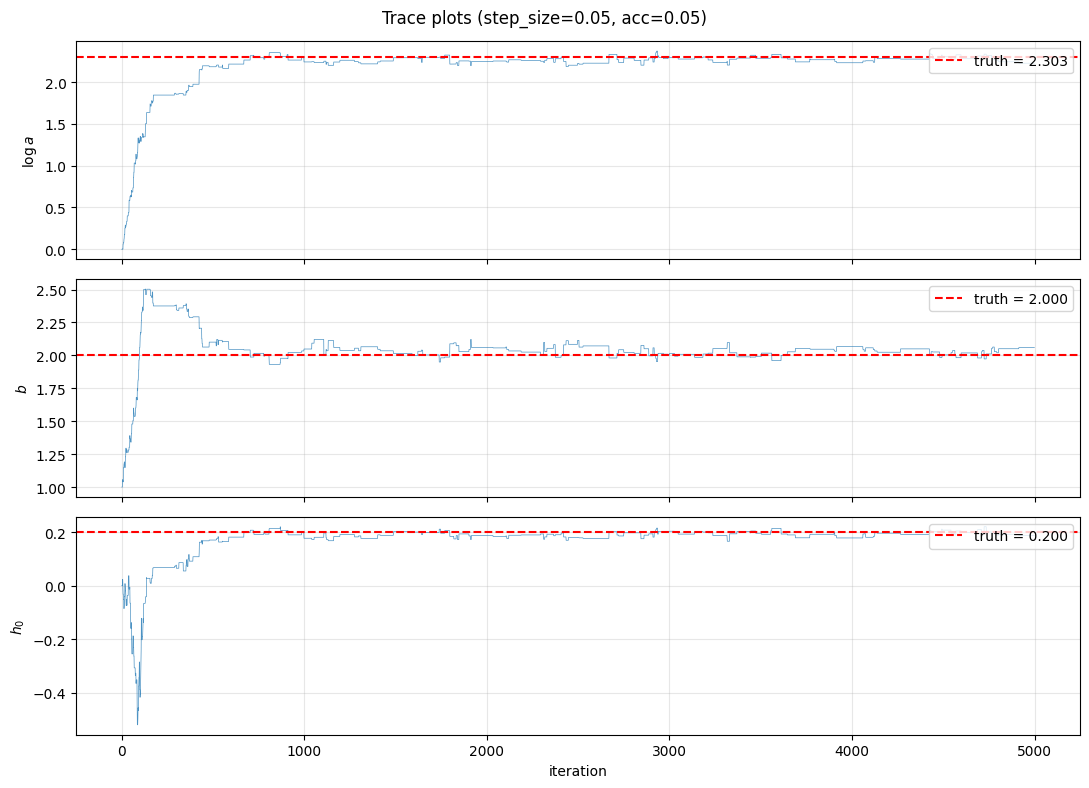

In [ ]:

sigma_known = 0.08
target = lambda theta: log_posterior(theta, h, Q, sigma_known)


theta0 = np.array([0.0, 1.0, 0.0])

rng = np.random.default_rng(seed=42)
samples, accepted = random_walk_metropolis_hastings(
    target_log_pdf=target,
    x0=theta0,
    n_samples=5000,
    step_size=0.05,
    rng=rng,
)

acceptance = accepted.mean()
print(f"acceptance rate: {acceptance:.3f}")
print(f"samples shape:   {samples.shape}")

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
labels = [r"$\log a$", r"$b$", r"$h_0$"]
true_vals = [np.log(10.0), 2.0, 0.20]

for i, (ax, label, true_val) in enumerate(zip(axes, labels, true_vals)):
    ax.plot(samples[:, i], lw=0.5, color="C0", alpha=0.8)
    ax.axhline(true_val, color="red", ls="--", lw=1.5, label=f"truth = {true_val:.3f}")
    ax.set_ylabel(label)
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("iteration")
fig.suptitle(f"Trace plots (step_size=0.05, acc={acceptance:.2f})")
plt.tight_layout()
plt.show()

In [10]:
step_candidates = [0.005, 0.010, 0.015, 0.025]
n_short = 5000

print(f"{'step':>8} {'acceptance':>12}")
print("-" * 22)

sweep_results = {}
for s in step_candidates:
    rng = np.random.default_rng(seed=42)
    _, acc = random_walk_metropolis_hastings(
        target_log_pdf=target,
        x0=theta0,
        n_samples=n_short,
        step_size=s,
        rng=rng,
    )
    sweep_results[s] = acc.mean()
    print(f"{s:>8.3f} {acc.mean():>12.3f}")

    step   acceptance
----------------------
   0.005        0.618
   0.010        0.425
   0.015        0.303
   0.025        0.150


In [ ]:
best_step = 0.015

rng = np.random.default_rng(seed=123)
samples_long, accepted_long = random_walk_metropolis_hastings(
    target_log_pdf=target,
    x0=theta0,
    n_samples=50000,
    step_size=best_step,
    rng=rng,
)

print(f"acceptance: {accepted_long.mean():.3f}")
print(f"samples:    {samples_long.shape}")

# Burn-in: ilk 5000'i at
burn_in = 5000
samples_post = samples_long[burn_in:]
print(f"after burn-in: {samples_post.shape}")

acceptance: 0.274
samples:    (50000, 3)
after burn-in: (45000, 3)


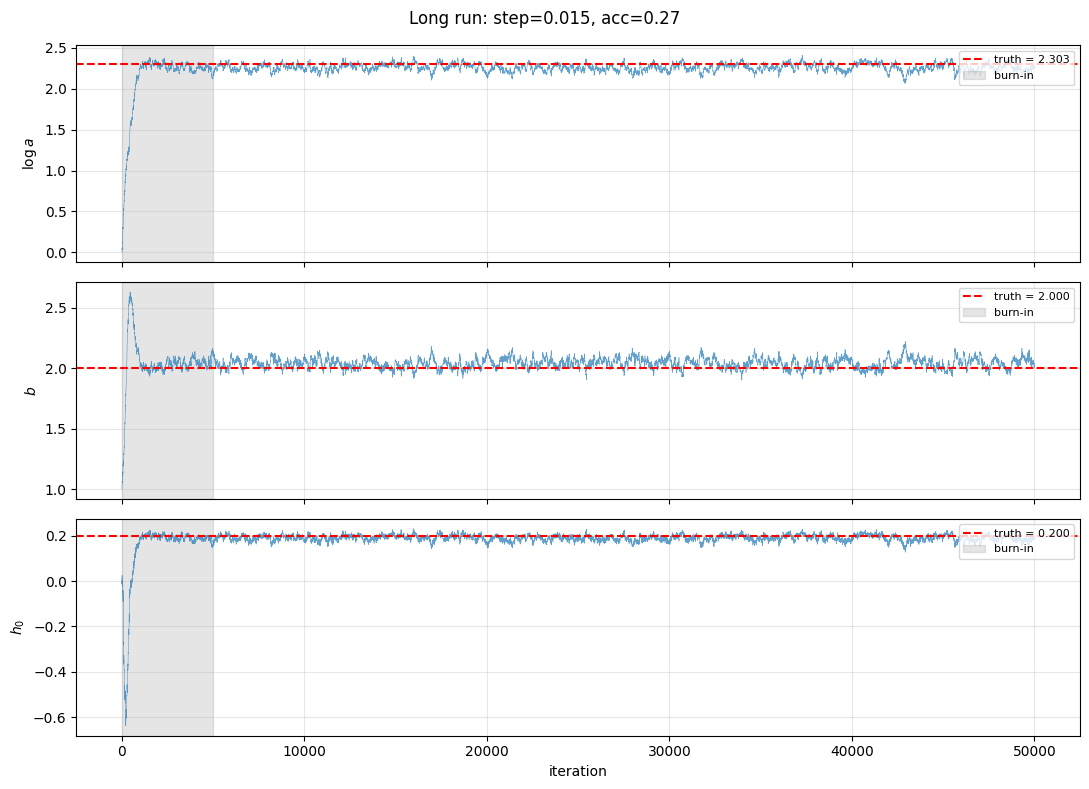

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
labels = [r"$\log a$", r"$b$", r"$h_0$"]
true_vals = [np.log(10.0), 2.0, 0.20]

for i, (ax, label, true_val) in enumerate(zip(axes, labels, true_vals)):
    ax.plot(samples_long[:, i], lw=0.4, color="C0", alpha=0.7)
    ax.axhline(true_val, color="red", ls="--", lw=1.5, label=f"truth = {true_val:.3f}")
    ax.axvspan(0, burn_in, color="gray", alpha=0.2, label="burn-in")
    ax.set_ylabel(label)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("iteration")
fig.suptitle(f"Long run: step={best_step}, acc={accepted_long.mean():.2f}")
plt.tight_layout()
plt.show()